Cycle 1: response = 15.0 Hz
Cycle 2: response = 14.7 Hz
Cycle 3: response = 14.4 Hz
Cycle 4: response = 14.1 Hz
Cycle 5: response = 13.8 Hz
Cycle 6: response = 13.5 Hz
Cycle 7: response = 13.2 Hz
Cycle 8: response = 12.9 Hz
Cycle 9: response = 12.6 Hz
Cycle 10: response = 12.3 Hz


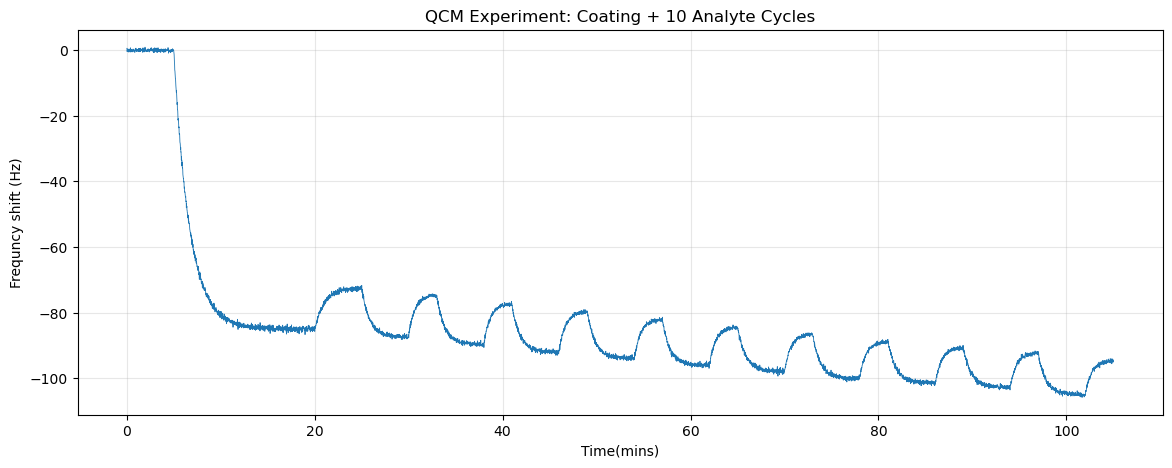

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

dt = 1 # 1 sec per measurement

# Phase 1: Baseline (5 mins = 300 points)
t_baseline = np.arange(0, 300, dt)
baseline_noise = np.random.normal(0, 0.3, 300)

# Phase 2: Coating of polymer nanoparticles (15 mins = 900 points)
t_coating = np.arange(300, 1200, dt)
coating_signal = -85 * (1 - np.exp(-(t_coating - 300) / 100))
coating = coating_signal + np.random.normal(0, 0.5, 900)

# Phase 3: Rinse
t_rinse = np.arange(1200, 1500, dt)
rinse_start = coating[-1]
recovery = abs(rinse_start) * 0.15 * (1 - np.exp(-(t_rinse - 1200) / 60)) # assuming 15% of the loosely bound materials rinse off, abs because it brings the signal closer to zero
rinse = rinse_start + recovery + np.random.normal(0, 0.4, 300)

all_time = [t_baseline, t_coating, t_rinse]
all_freq = [baseline_noise, coating, rinse]

current_time = 1500
current_level = rinse[-1]

for cycle in range(10):
    degradation = 1.0 - 0.02 * cycle
    response = -15.0 * degradation

    #Analyte exposure
    t_exp = np.arange(current_time, current_time + 300, dt)
    exp_curve = response * (1 - np.exp(-(t_exp - current_time) / 50))
    exposure = current_level + exp_curve + np.random.normal(0, 0.4, 300)

    all_time.append(t_exp)
    all_freq.append(exposure)
    current_time = current_time + 300

    #Analyte rinse (3 mins = 180 points)
    t_rns = np.arange(current_time, current_time + 180 , dt)
    drop = abs(exposure[-1] - current_level)

    recovery_amount = drop * 0.85
    recovery_curve = recovery_amount * (1 - np.exp(-(t_rns - current_time) / 40))

    rns = exposure[-1] + recovery_curve + np.random.normal(0, 0.35, 180)

    all_time.append(t_rns)
    all_freq.append(rns)
    current_time = current_time + 180

    current_level = rns[-1]

    print(f"Cycle {cycle + 1}: response = {abs(response):.1f} Hz")

time_all = np.concatenate(all_time)
frequency_all = np.concatenate(all_freq)

plt.figure(figsize=(14, 5))
plt.plot(time_all/60, frequency_all, linewidth = 0.6)
plt.xlabel("Time(mins)")
plt.ylabel("Frequncy shift (Hz)")
plt.title("QCM Experiment: Coating + 10 Analyte Cycles")
plt.grid(True, alpha=0.3)
plt.show()

## Version 2: Rebuilt with functions

In [2]:
def generate_baseline(duration, noise_level=0.3):
    n_points = int(duration)
    time = np.arange(0, duration, 1)
    signal = np.random.normal(0, noise_level, n_points)
    return time, signal

def generate_adsorption(duration, final_value, tau, noise_level=0.5):
    n_points = int(duration)
    time = np.arange(0, duration, 1)
    signal = final_value * (1 - np.exp(-time / tau))
    noise = np.random.normal(0, noise_level, n_points)
    return time, signal + noise

def generate_rinse(duration, start_value, recovery_fraction, tau, noise_level=0.4):
    n_points = int(duration)
    time = np.arange(0, duration, 1)
    recovery = abs(start_value) * recovery_fraction * (1 - np.exp(-time / tau))
    signal = start_value + recovery
    noise = np.random.normal(0, noise_level, n_points)
    return time, signal + noise

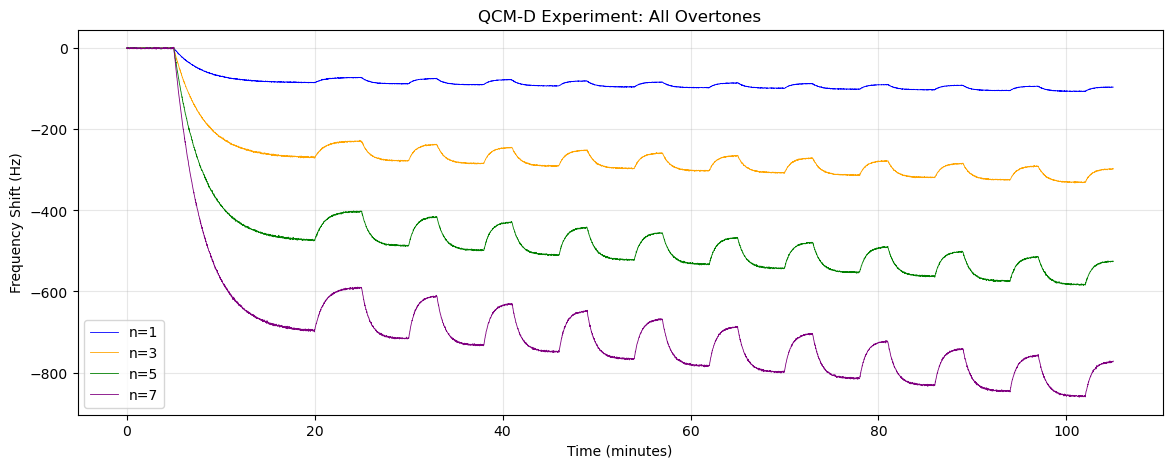

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def generate_baseline(duration, noise_level=0.3):
    n_points = int(duration)
    time = np.arange(0, duration, 1)
    signal = np.random.normal(0, noise_level, n_points)
    return time, signal

def generate_adsorption(duration, final_value, tau, noise_level=0.5):
    n_points = int(duration)
    time = np.arange(0, duration, 1)
    signal = final_value * (1 - np.exp(-time / tau))
    noise = np.random.normal(0, noise_level, n_points)
    return time, signal + noise

def generate_rinse(duration, start_value, recovery_fraction, tau, noise_level=0.4):
    n_points = int(duration)
    time = np.arange(0, duration, 1)
    recovery = abs(start_value) * recovery_fraction * (1 - np.exp(-time / tau))
    signal = start_value + recovery
    noise = np.random.normal(0, noise_level, n_points)
    return time, signal + noise

all_time = []
plt.figure(figsize=(14, 5))
colors = {1: 'blue', 3: 'orange', 5: 'green', 7: 'purple'}

for overtone_n in [1, 3, 5, 7]:

    # Overtone scaling
    scale = overtone_n * (1 + 0.03 * (overtone_n - 1))
    noise_scale = np.sqrt(overtone_n)

    all_time = []
    all_freq = []
    current_time = 0

    # Baseline (5 min)
    t, sig = generate_baseline(300, 0.3 * noise_scale)
    all_time.append(t + current_time)
    all_freq.append(sig)
    current_time += 300

    # Coating (15 min) - scaled by overtone
    t, sig = generate_adsorption(900, -85 * scale, 180, 0.5 * noise_scale)
    sig = sig + all_freq[-1][-1]
    all_time.append(t + current_time)
    all_freq.append(sig)
    current_time += 900

    # Post-coating rinse (5 min)
    coating_end = all_freq[-1][-1]
    t, sig = generate_rinse(300, coating_end, 0.15, 60, 0.4 * noise_scale)
    all_time.append(t + current_time)
    all_freq.append(sig)
    current_time += 300

    # 10 analyte cycles
    current_level = all_freq[-1][-1]
    base_response = -15.0 * scale  # scaled by overtone

    for cycle in range(10):
        degradation = 1.0 - 0.02 * cycle
        response = base_response * degradation

        # Analyte exposure (5 min)
        t, sig = generate_adsorption(300, response, 50, 0.4 * noise_scale)
        sig = sig + current_level
        all_time.append(t + current_time)
        all_freq.append(sig)
        current_time += 300

        # Analyte rinse (3 min)
        t_rns = np.arange(0, 180, 1)
        exp_end = all_freq[-1][-1]
        drop = abs(exp_end - current_level)
        recovery_amount = drop * 0.85
        recovery_curve = recovery_amount * (1 - np.exp(-t_rns / 40))
        rns = exp_end + recovery_curve + np.random.normal(0, 0.35 * noise_scale, 180)

        all_time.append(t_rns + current_time)
        all_freq.append(rns)
        current_time += 180

        current_level = rns[-1]

    # Combine this overtone's data
    time_full = np.concatenate(all_time)
    freq_full = np.concatenate(all_freq)

    # Plot this overtone
    plt.plot(time_full / 60, freq_full, color=colors[overtone_n],
             label=f'n={overtone_n}', linewidth=0.6)

plt.xlabel("Time (minutes)")
plt.ylabel("Frequency Shift (Hz)")
plt.title("QCM-D Experiment: All Overtones")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()